# How to choose a neuron model

**Task.** Pick the right spiking neuron model for your network and see how a few
of them respond to the same input.

**Audience.** Simulation. Assumes you've done :doc:`../tutorials/01-first-neuron`.

`brainpy.state` ships a family of point-neuron models, from the minimal
integrate-and-fire to biophysical Hodgkin–Huxley. They all share the same
interface — construct with a size and parameters, advance with a call, read
spikes with `get_spike()` — so swapping one for another is a one-line change.
This guide drives several under an identical current so you can compare their
firing behavior, then points you to the full list in the API reference.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Drive several models with the same current

We build one neuron of each kind, give them all the same step current, and
record their membrane potentials. Each model has its own natural parameter
units and scales, so we keep parameters close to each model's defaults.

In [2]:
def run(neuron, current, t_stop=200. * u.ms):
    brainstate.nn.init_all_states(neuron)

    def step(t):
        with brainstate.environ.context(t=t):
            neuron(current)
            return neuron.V.value

    times = u.math.arange(0. * u.ms, t_stop, brainstate.environ.get_dt())
    return times, brainstate.transform.for_loop(step, times)


with brainstate.environ.context(dt=0.05 * u.ms):
    models = {
        'LIFRef': brainpy.state.LIFRef(
            1, tau=20. * u.ms, tau_ref=5. * u.ms, V_rest=-60. * u.mV,
            V_th=-50. * u.mV, V_reset=-60. * u.mV),
        'ALIF': brainpy.state.ALIF(
            1, tau=20. * u.ms, tau_a=200. * u.ms, V_rest=-60. * u.mV,
            V_th=-50. * u.mV, V_reset=-60. * u.mV),
        'ExpIF': brainpy.state.ExpIF(
            1, tau=20. * u.ms, V_rest=-60. * u.mV, V_reset=-60. * u.mV),
    }
    traces = {name: run(m, 25. * u.mA) for name, m in models.items()}

## Compare the responses

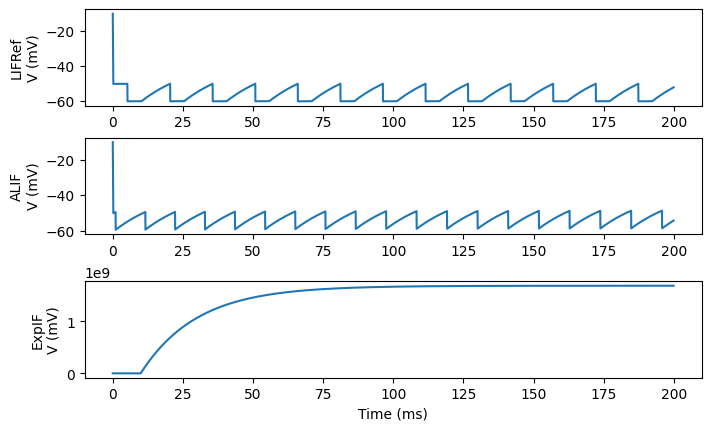

In [3]:
fig, gs = braintools.visualize.get_figure(len(traces), 1, 1.4, 7.0)
for i, (name, (times, vs)) in enumerate(traces.items()):
    ax = fig.add_subplot(gs[i, 0])
    ax.plot(times.to_decimal(u.ms), vs.to_decimal(u.mV)[:, 0])
    ax.set_ylabel(name + '\nV (mV)')
ax.set_xlabel('Time (ms)')
plt.show()

### Choosing a model

`LIFRef` (leaky integrate-and-fire with a refractory period) fires regularly;
`ALIF` adds spike-frequency adaptation (the inter-spike interval grows over
time); `ExpIF` has a sharper, exponential spike onset. Choose based on the
phenomenon you need:

- **Minimal cost:** `IF`, `LIF`, `LIFRef`.
- **Adaptation:** `ALIF`, `Gif`, `AdExIF`, `AdQuaIF`.
- **Realistic spike onset:** `ExpIF`, `AdExIF`, `QuaIF`.
- **Rich single-neuron dynamics:** `Izhikevich`, `HindmarshRose`.
- **Full biophysics:** `HH`, `WangBuzsakiHH`, `MorrisLecar`.

## Where to find every model

This is only a sample. The authoritative directory — with every neuron's full
signature, parameters, and equations — is the API reference:

- :doc:`/apis/brainpy-neurons` — all BrainPy-style neuron models.

## See also

- :doc:`sim-coba-cuba-synapses` — connect your chosen neurons with synapses.
- :doc:`/concepts/model-anatomy` — the shared `Dynamics → Neuron` interface.
- :doc:`../tutorials/03-ei-balanced-network` — a full network built from LIFRef.